# Semana 5 – Actividad 5
## Red neuronal para clasificación multiclase sin convolución

En este notebook se implementa una red neuronal básica usando TensorFlow y Keras para resolver un problema de clasificación multiclase.

Se utiliza el dataset MNIST, compuesto por imágenes de dígitos escritos a mano del 0 al 9.

El objetivo es comparar dos configuraciones de entrenamiento modificando la tasa de aprendizaje, manteniendo constantes los demás elementos del modelo.

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [33]:
# Cargar el dataset MNIST

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Datos de entrenamiento:", x_train.shape)
print("Etiquetas de entrenamiento:", y_train.shape)
print("Datos de prueba:", x_test.shape)
print("Etiquetas de prueba:", y_test.shape)

Datos de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Datos de prueba: (10000, 28, 28)
Etiquetas de prueba: (10000,)


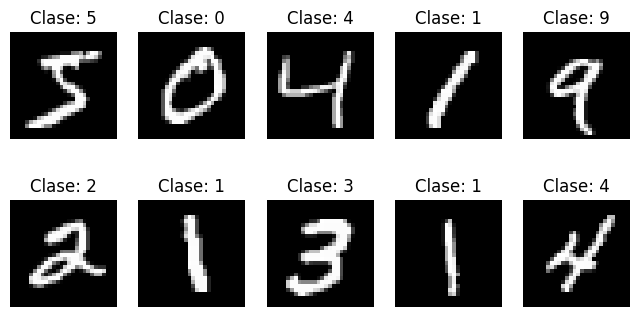

In [34]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Clase: " + str(y_train[i]))
    plt.axis("off")

plt.show()

In [35]:
# Normalizar imágenes para que los valores queden entre 0 y 1

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalización realizada correctamente")

Normalización realizada correctamente


## Modelo utilizado

Se implementa una red neuronal densa, sin capas convolucionales.

La imagen de entrada se aplana con una capa Flatten, luego pasa por capas Dense y finalmente se obtiene una salida de 10 neuronas, una por cada clase del dataset MNIST.

Las clases corresponden a los dígitos del 0 al 9.

In [36]:
def crear_modelo(learning_rate):
    modelo = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    optimizador = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    modelo.compile(
        optimizer=optimizador,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

## Configuración 1

Modelo entrenado con tasa de aprendizaje de 0.001.

Esta configuración usa una tasa de aprendizaje moderada, que normalmente permite un entrenamiento más estable.

In [24]:
modelo_1 = crear_modelo(learning_rate=0.001)

historia_1 = modelo_1.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9124 - loss: 0.3073 - val_accuracy: 0.9552 - val_loss: 0.1551
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9625 - loss: 0.1265 - val_accuracy: 0.9682 - val_loss: 0.1134
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9737 - loss: 0.0857 - val_accuracy: 0.9696 - val_loss: 0.1078
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9808 - loss: 0.0630 - val_accuracy: 0.9726 - val_loss: 0.0902
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9840 - loss: 0.0508 - val_accuracy: 0.9748 - val_loss: 0.0846
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 0.9589 - val_loss: 0.1460
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9907 - loss: 0.0310 - val_accuracy: 0.9734 - val_loss: 0.0960
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9913 - loss: 0.0272 - val_accuracy: 0.

In [25]:
loss_1, accuracy_1 = modelo_1.evaluate(x_test, y_test)

print("Configuración 1")
print("Learning rate: 0.001")
print("Loss:", loss_1)
print("Accuracy:", accuracy_1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.0920
Configuración 1
Learning rate: 0.001
Loss: 0.09201868623495102
Accuracy: 0.9749000072479248


## Configuración 2

Modelo entrenado con tasa de aprendizaje de 0.01.

Esta configuración usa una tasa de aprendizaje más alta. Puede acelerar el entrenamiento, pero también puede generar mayor inestabilidad.

In [26]:
modelo_2 = crear_modelo(learning_rate=0.01)

historia_2 = modelo_2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9229 - loss: 0.2541 - val_accuracy: 0.9499 - val_loss: 0.1707
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9565 - loss: 0.1486 - val_accuracy: 0.9640 - val_loss: 0.1323
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9652 - loss: 0.1234 - val_accuracy: 0.9538 - val_loss: 0.1715
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9672 - loss: 0.1157 - val_accuracy: 0.9632 - val_loss: 0.1469
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9709 - loss: 0.1053 - val_accuracy: 0.9650 - val_loss: 0.1403
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9737 - loss: 0.0941 - val_accuracy: 0.9653 - val_loss: 0.1496
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9759 - loss: 0.0901 - val_accuracy: 0.9613 - val_loss: 0.1776
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9747 - loss: 0.0927 - val_accuracy: 0.

In [27]:
loss_2, accuracy_2 = modelo_2.evaluate(x_test, y_test)

print("Configuración 2")
print("Learning rate: 0.01")
print("Loss:", loss_2)
print("Accuracy:", accuracy_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1905
Configuración 2
Learning rate: 0.01
Loss: 0.19050544500350952
Accuracy: 0.9656000137329102


In [28]:
comparacion = pd.DataFrame({
    "Configuración": ["Modelo 1", "Modelo 2"],
    "Learning Rate": [0.001, 0.01],
    "Batch Size": [64, 64],
    "Épocas": [10, 10],
    "Loss prueba": [loss_1, loss_2],
    "Accuracy prueba": [accuracy_1, accuracy_2]
})

comparacion

,Configuración,Learning Rate,Batch Size,Épocas,Loss prueba,Accuracy prueba
0,Modelo 1,0.001,64,10,0.092019,0.9749
1,Modelo 2,0.010,64,10,0.190505,0.9656


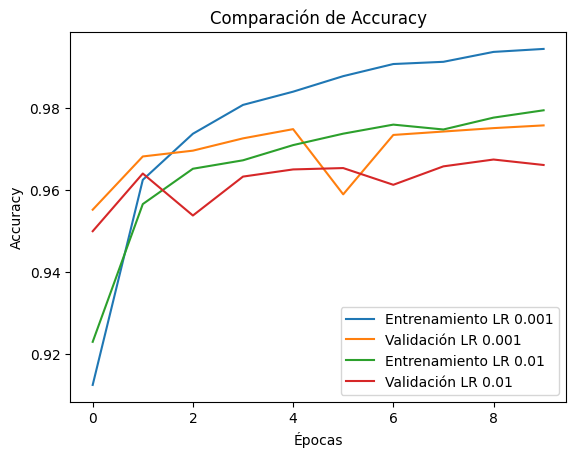

In [29]:
plt.plot(historia_1.history["accuracy"], label="Entrenamiento LR 0.001")
plt.plot(historia_1.history["val_accuracy"], label="Validación LR 0.001")

plt.plot(historia_2.history["accuracy"], label="Entrenamiento LR 0.01")
plt.plot(historia_2.history["val_accuracy"], label="Validación LR 0.01")

plt.title("Comparación de Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

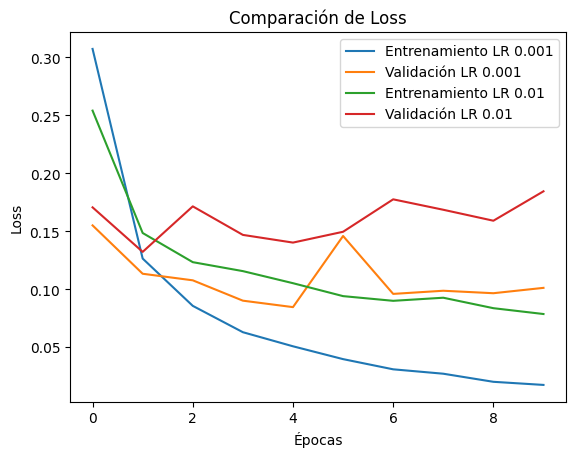

In [30]:
plt.plot(historia_1.history["loss"], label="Entrenamiento LR 0.001")
plt.plot(historia_1.history["val_loss"], label="Validación LR 0.001")

plt.plot(historia_2.history["loss"], label="Entrenamiento LR 0.01")
plt.plot(historia_2.history["val_loss"], label="Validación LR 0.01")

plt.title("Comparación de Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Análisis de resultados

Se compararon dos configuraciones de entrenamiento manteniendo constante la arquitectura del modelo, el número de épocas y el tamaño de lote. La variable modificada fue la tasa de aprendizaje.

La configuración con learning rate de 0.001 presentó un entrenamiento más estable, ya que el loss disminuyó de manera progresiva y el accuracy aumentó de forma controlada.

La configuración con learning rate de 0.01 permitió avanzar más rápido al inicio, pero puede presentar mayor variación entre entrenamiento y validación. Esto indica que una tasa de aprendizaje alta no siempre garantiza mejor desempeño final.

En términos de velocidad de convergencia, la segunda configuración puede aprender más rápido en las primeras épocas. Sin embargo, la primera configuración suele ofrecer mayor estabilidad durante el entrenamiento.

## Conclusiones

1. La tasa de aprendizaje influye directamente en la estabilidad del entrenamiento.

2. Un learning rate bajo permite un ajuste más progresivo y controlado del modelo.

3. Un learning rate alto puede acelerar la convergencia inicial, pero también puede generar mayor inestabilidad.

4. La comparación fue válida porque se mantuvieron constantes la arquitectura, el número de épocas y el tamaño de lote.

5. Para mejorar el modelo se podrían probar más configuraciones, ajustar el batch size o aumentar el número de épocas.